In [1]:
import glob
import json
import logging
import sys
from functools import partial
from os.path import dirname

import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold

console_handler = logging.StreamHandler(sys.stdout)
file_handler = logging.FileHandler("logs/anysleep_cap_insomnia_sfs.log", encoding="utf-8", mode="w")
formatter = logging.Formatter(
    "%(asctime)s [%(levelname)s] %(name)s: %(message)s",
    "%Y-%m-%d %H:%M:%S",
)
console_handler.setFormatter(formatter)
file_handler.setFormatter(formatter)
logging.basicConfig(
    level=logging.INFO,
    handlers=[console_handler, file_handler],
)
logger = logging.getLogger(__name__)


def calc_mode(data, axis=0):
    bins = np.apply_along_axis(
        lambda x: np.bincount(x, minlength=5), axis=axis, arr=data
    )
    # resolve ties randomly by adding a small random number to the counts
    rand_mat = np.random.random_sample(bins.shape)
    bins = bins + rand_mat
    return np.argmax(bins, axis=axis)


cap_preds_glob = "../../examples/output/CAP/predictions*_c.npz"
cap_preds_files = sorted(glob.glob(cap_preds_glob))
print(cap_preds_files)

keys_per_run_per_sr = {}
for pred_file in cap_preds_files:
    f_handle = np.load(pred_file)
    keys = f_handle.files

    for k in keys:
        model_run = k.split("#")[1]
        sleep_stage_sr = int(k.split('#')[2])
        if model_run not in keys_per_run_per_sr:
            keys_per_run_per_sr[model_run] = {}
        if sleep_stage_sr not in keys_per_run_per_sr[model_run]:
            keys_per_run_per_sr[model_run][sleep_stage_sr] = []
        keys_per_run_per_sr[model_run][sleep_stage_sr].append([f_handle, k])

epoch_sr = 128 * 30
n_classes = 5
feature_block_duration = int(1.5 * 60 * 2)  # in epochs
possible_triplets = [f"{i}{j}{k}" for i in range(n_classes) for j in range(n_classes) for k in range(n_classes)
                     if i != j and j != k]


def calc_features(sleep_sr, preds_dict, preds_per_epoch):
    features = {}

    for rec in preds_dict.keys():
        preds = preds_dict[rec]

        sleep_start = np.where(preds_per_epoch[rec] != 0)[0][0]
        sleep_end = np.where(preds_per_epoch[rec] != 0)[0][-1]

        features[rec] = []
        for i in range(sleep_start, sleep_end, feature_block_duration):
            features[rec].append([0] * len(possible_triplets))
            features_block = preds[i * sleep_sr:min(i + feature_block_duration, sleep_end) * sleep_sr]
            features_block_1r = np.r_[features_block[0], features_block[:-1]]
            features_block_1l = np.r_[features_block[1:], features_block[-1]]

            # find triplets with a different element in the middle
            triplet_mask = np.where(((features_block - features_block_1r) != 0)
                                    & ((features_block - features_block_1l) != 0))[0]

            for trip_idx in triplet_mask:
                trip_str = f"{features_block[trip_idx - 1]}{features_block[trip_idx]}{features_block[trip_idx + 1]}"
                features[rec][-1][possible_triplets.index(trip_str)] += 1

    return features

['../../examples/output/CAP/predictions_c.npz']


In [2]:
import re

subj_insomnia_dict = {}
for model_dict in keys_per_run_per_sr.values():
    for sr_dict in model_dict.values():
        for _, f in sr_dict:
            s_id = f.split("#")[0]
            coh = re.split("\d", s_id)[0]
            if coh == "n":
                subj_insomnia_dict[s_id] = 0
            if coh == "ins":
                subj_insomnia_dict[s_id] = 1

subj_insomnia_dict

{'ins9': 1,
 'n9': 0,
 'n13': 0,
 'n8': 0,
 'ins6': 1,
 'n10': 0,
 'ins4': 1,
 'ins8': 1,
 'n15': 0,
 'n2': 0,
 'n1': 0,
 'n5': 0,
 'ins5': 1,
 'n7': 0,
 'n14': 0,
 'n11': 0,
 'n16': 0,
 'ins3': 1,
 'n4': 0,
 'ins2': 1,
 'n6': 0,
 'ins1': 1,
 'ins7': 1,
 'n12': 0,
 'n3': 0}

In [3]:
from sklearn.ensemble import RandomForestClassifier
from concurrent.futures import ProcessPoolExecutor
from sklearn.metrics import f1_score


def train_and_predict(features, train_recs, test_recs, n_exps):
    x_train = []
    y_train = []
    x_test = []
    y_test = []
    subject_mapping_train = []
    subject_mapping_test = []

    for subject_name, subj_features in features.items():
        if subject_name not in subj_insomnia_dict:
            print(f"No insomnia label for {subject_name}")
            continue
        if subject_name in train_recs:
            x_train.extend(subj_features)
            y_train.extend([subj_insomnia_dict[subject_name]] * len(subj_features))
            subject_mapping_train.extend([subject_name] * len(subj_features))
        elif subject_name in test_recs:
            x_test.extend(subj_features)
            y_test.extend([subj_insomnia_dict[subject_name]] * len(subj_features))
            subject_mapping_test.extend([subject_name] * len(subj_features))
        else:
            raise ValueError(f"Subject {subject_name} not in train or test set")

    x_train = np.array(x_train)
    y_train = np.array(y_train)
    x_test = np.array(x_test)
    y_test = np.array(y_test)
    subject_mapping_train = np.array(subject_mapping_train)
    subject_mapping_test = np.array(subject_mapping_test)

    label_insomnia = []
    predict_insomnia = []
    selected_features = []
    sfs_scores = []
    for run_num in range(n_exps):
        y_pred, sel_feat, cv_scores = fit_and_predict(run_num, x_train, y_train, x_test, subject_mapping_train)

        y_test_subj = []
        y_pred_subj = []
        for subj in np.unique(subject_mapping_test):
            assert np.all(y_test[subject_mapping_test == subj] == y_test[subject_mapping_test == subj][0])
            y_test_subj.append(y_test[subject_mapping_test == subj][0])
            y_pred_subj.append(np.mean(y_pred[subject_mapping_test == subj]))

        label_insomnia.append(y_test_subj)
        predict_insomnia.append(y_pred_subj)
        selected_features.append(sel_feat)
        sfs_scores.append(cv_scores)

    return label_insomnia, predict_insomnia, selected_features, sfs_scores


with open("rnd_parameter_map_rndfcls.json", "r") as f:
    rnd_parameter_map = json.load(f)


def fit_and_predict(run_num, x_train, y_train, x_test, subject_mapping_train):
    clf = RandomForestClassifier(n_estimators=200, criterion="gini", class_weight="balanced",
                                 max_depth=rnd_parameter_map[run_num]["max_tree_depth"],
                                 min_samples_leaf=rnd_parameter_map[run_num]["min_samples_leaf"],
                                 min_samples_split=rnd_parameter_map[run_num]["min_samples_split"],
                                 max_features=rnd_parameter_map[run_num]["max_features"])

    n_features_to_select = 5
    selected_features_idcs = []
    scores = []
    for i in range(n_features_to_select):
        remain_feat = np.array(list(set(range(x_train.shape[1])) - set(selected_features_idcs)))

        with ProcessPoolExecutor(max_workers=32) as executor:
            partial_f = partial(sfs, x_train, y_train, clf, selected_features_idcs, subject_mapping_train)
            results = np.array(list(executor.map(partial_f, remain_feat)))
            best_score = max(results)
            best_feat = remain_feat[results == best_score]
            np.random.shuffle(best_feat)  # to avoid bias in selection
            best_feat = int(best_feat[0])  # take first if multiple features have same score
            logger.info(f"Previous features: {selected_features_idcs}, remaining features {remain_feat.tolist()}, "
                        f"scores {[f'{r:.4f}' for r in results]}, selected feature {best_feat}")

        selected_features_idcs = selected_features_idcs + [best_feat]
        scores.append(best_score)

    x_train_best_feat = x_train[:, selected_features_idcs]
    x_test_best_feat = x_test[:, selected_features_idcs]
    clf.fit(x_train_best_feat, y_train)
    y_pred = clf.predict(x_test_best_feat)

    return y_pred, selected_features_idcs, scores


def sfs(x_train, y_train, clf, previous_features, subject_mapping_train, current_feature):
    x_train_temp = x_train[:, previous_features + [current_feature]]

    subjects = np.unique(subject_mapping_train)
    subj_labels = np.array([y_train[subject_mapping_train == subj][0] for subj in subjects])
    skf = StratifiedKFold(n_splits=5, shuffle=True)
    folds = skf.split(subjects, subj_labels)
    scores = []
    for tr_subj, te_subj in folds:
        tr_subj_mask = np.isin(subject_mapping_train, subjects[tr_subj])
        te_subj_mask = np.isin(subject_mapping_train, subjects[te_subj])
        clf.fit(x_train_temp[tr_subj_mask], y_train[tr_subj_mask])
        y_pred = clf.predict(x_train_temp[te_subj_mask])

        y_pred_subj = []
        for subj in subjects[te_subj]:
            y_pred_subj.append(np.mean(y_pred[subject_mapping_train[te_subj_mask] == subj]))
        y_pred_subj = np.array(y_pred_subj)
        y_pred_subj_bin = (np.array(y_pred_subj) > 0.5).astype(int)
        y_pred_subj_bin[y_pred_subj == 0.5] = np.random.randint(0, 2, size=np.sum(y_pred_subj == 0.5))

        y_true_subj = subj_labels[te_subj]
        scores.append(f1_score(y_true_subj, y_pred_subj_bin, average="macro", zero_division=1))
    return np.mean(scores)

In [4]:
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

n_exps = 50
srs = [1, 32]

# data split
first_model_run = list(keys_per_run_per_sr.keys())[0]
all_rec_ids = []
all_cohs = []
for _, k in keys_per_run_per_sr[first_model_run][1]:
    s_id = k.split("#")[0]
    if s_id in subj_insomnia_dict:
        all_rec_ids.append(s_id)
        all_cohs.append(subj_insomnia_dict[s_id])
train_recs, test_recs = train_test_split(all_rec_ids, test_size=0.2, random_state=42, stratify=all_cohs, shuffle=True)
logger.info(train_recs)
logger.info(test_recs)

mf1_scores = {}
sfs_features = {}
sfs_scores = {}
for model_run, files_per_sr in keys_per_run_per_sr.items():
    logger.info(f"Model epoch: {model_run}")
    preds_per_epoch = {}
    for file in files_per_sr[1]:  # 1 = 30s epochs
        preds_per_epoch[file[1].split("#")[0]] = file[0][file[1]]
    mf1_scores[model_run] = {}
    sfs_features[model_run] = {}
    sfs_scores[model_run] = {}
    for sleep_stage_sr in srs:
        files = files_per_sr[sleep_stage_sr]
        preds_per_window_sr = {}
        for file in files:
            preds_per_window_sr[file[1].split("#")[0]] = file[0][file[1]]
        features = calc_features(sleep_stage_sr, preds_per_window_sr, preds_per_epoch)
        label_insomnia, predict_insomnia, sel_feat, feat_scores = train_and_predict(features, train_recs, test_recs, n_exps)

        predict_insomnia = np.array(predict_insomnia)
        label_insomnia = np.array(label_insomnia)
        sel_feat = np.array(sel_feat)
        feat_scores = np.array(feat_scores)  # shape: (n_exps, n_features)

        predict_insomnia_bin = (predict_insomnia > 0.5).astype(int)
        predict_insomnia_bin[predict_insomnia == 0.5] = np.random.randint(0, 2, size=np.sum(predict_insomnia == 0.5))

        f1_array = []
        for i_exp in range(n_exps):
            cm = confusion_matrix(label_insomnia[i_exp], predict_insomnia_bin[i_exp])
            print(cm)  # TODO remove this
            precs, recs, f1s, _ = precision_recall_fscore_support(label_insomnia[i_exp], predict_insomnia_bin[i_exp],
                                                                  average=None, zero_division=1)
            f1_array.append(np.mean(f1s))

        logger.info(f"{sleep_stage_sr} sleep stages per epoch")
        logger.info(f"Avg. Makro F1: {np.mean(f1_array)}")
        logger.info(f"Std. Makro F1: {np.std(f1_array)}")
        logger.info("")
        mf1_scores[model_run][sleep_stage_sr] = f1_array
        sfs_features[model_run][sleep_stage_sr] = sel_feat
        sfs_scores[model_run][sleep_stage_sr] = feat_scores

2026-03-23 10:20:52 [INFO] __main__: ['ins1', 'n13', 'n16', 'n9', 'n15', 'n14', 'n6', 'n11', 'n8', 'n12', 'n7', 'ins7', 'n2', 'ins4', 'ins3', 'ins9', 'n3', 'ins2', 'ins8', 'n5']


2026-03-23 10:20:52 [INFO] __main__: ['ins5', 'n1', 'n10', 'n4', 'ins6']


2026-03-23 10:20:52 [INFO] __main__: Model epoch: anysleep-run1


No insomnia label for plm9
No insomnia label for plm8
No insomnia label for nfle13
No insomnia label for rbd14
No insomnia label for rbd12
No insomnia label for nfle26
No insomnia label for nfle40
No insomnia label for nfle7
No insomnia label for rbd18
No insomnia label for rbd8
No insomnia label for nfle10
No insomnia label for rbd7
No insomnia label for narco3
No insomnia label for nfle38
No insomnia label for nfle11
No insomnia label for nfle5
No insomnia label for plm10
No insomnia label for nfle37
No insomnia label for narco2
No insomnia label for nfle24
No insomnia label for rbd13
No insomnia label for sdb3
No insomnia label for rbd19
No insomnia label for nfle20
No insomnia label for nfle15
No insomnia label for rbd15
No insomnia label for nfle25
No insomnia label for nfle21
No insomnia label for narco1
No insomnia label for rbd10
No insomnia label for nfle30
No insomnia label for nfle17
No insomnia label for rbd5
No insomnia label for rbd17
No insomnia label for nfle29
No insom

2026-03-23 10:20:55 [INFO] __main__: Previous features: [], remaining features [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79], scores ['0.5381', '0.7067', '0.2990', '0.2990', '0.2990', '0.2990', '0.2990', '0.2990', '0.2990', '0.2990', '0.2990', '0.2990', '0.2990', '0.2990', '0.2990', '0.2990', '0.3714', '0.2990', '0.2990', '0.2990', '0.3448', '0.3905', '0.2990', '0.2990', '0.2990', '0.2990', '0.2990', '0.2990', '0.2990', '0.2990', '0.2990', '0.2990', '0.4848', '0.3590', '0.2990', '0.2990', '0.2990', '0.2590', '0.2990', '0.2990', '0.2990', '0.2990', '0.4990', '0.2990', '0.2990', '0.2990', '0.3181', '0.2990', '0.2990', '0.3133', '0.2990', '0.2990', '0.2990', '0.2990', '0.2990', '0.2990', '0.2990', '0.2990', '0.3257', '0.2990', '

...

2026-03-23 11:40:44 [INFO] __main__: Previous features: [4, 79, 77, 67], remaining features [0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 68, 69, 70, 71, 72, 73, 74, 75, 76, 78], scores ['0.8667', '0.6457', '0.8933', '0.8933', '0.7933', '0.8933', '0.9467', '0.8933', '0.8933', '0.9467', '0.8933', '0.8400', '0.9467', '0.8933', '0.8933', '0.8400', '0.8467', '0.8933', '0.9467', '0.7933', '0.8133', '0.7933', '0.8933', '0.8933', '0.8933', '0.8467', '0.8933', '0.8400', '0.8467', '0.8933', '0.8933', '0.8667', '0.7790', '0.8857', '0.8324', '0.6790', '0.7790', '0.8324', '0.8324', '0.9000', '0.6648', '0.5657', '0.8324', '0.8467', '0.8857', '0.7857', '0.8857', '0.8857', '0.7067', '0.7257', '0.8857', '0.8857', '0.6648', '0.6648', '0.6648', '0.8324', '0.7714', '0.8324', '0.9000', '0.8857', '0.

[[3 0]
 [1 1]]
[[3 0]
 [0 2]]
[[2 1]
 [1 1]]
[[3 0]
 [1 1]]
[[3 0]
 [1 1]]
[[3 0]
 [1 1]]
[[2 1]
 [1 1]]
[[3 0]
 [0 2]]
[[2 1]
 [0 2]]
[[2 1]
 [0 2]]
[[2 1]
 [0 2]]
[[3 0]
 [1 1]]
[[2 1]
 [1 1]]
[[3 0]
 [0 2]]
[[2 1]
 [0 2]]
[[3 0]
 [0 2]]
[[3 0]
 [1 1]]
[[3 0]
 [1 1]]
[[3 0]
 [0 2]]
[[1 2]
 [0 2]]
[[2 1]
 [0 2]]
[[3 0]
 [1 1]]
[[2 1]
 [0 2]]
[[3 0]
 [1 1]]
[[3 0]
 [1 1]]
[[3 0]
 [1 1]]
[[3 0]
 [0 2]]
[[2 1]
 [0 2]]
[[3 0]
 [1 1]]
[[3 0]
 [0 2]]
[[2 1]
 [0 2]]
[[3 0]
 [1 1]]
[[3 0]
 [1 1]]
[[3 0]
 [0 2]]
[[3 0]
 [0 2]]
[[1 2]
 [0 2]]
[[3 0]
 [1 1]]
[[2 1]
 [0 2]]
[[3 0]
 [0 2]]
[[3 0]
 [1 1]]
[[2 1]
 [1 1]]
[[3 0]
 [0 2]]
[[3 0]
 [0 2]]
[[2 1]
 [1 1]]
[[3 0]
 [1 1]]
[[3 0]
 [1 1]]
[[2 1]
 [1 1]]
[[3 0]
 [1 1]]
[[2 1]
 [1 1]]
[[3 0]
 [1 1]]
2026-03-23 11:40:44 [INFO] __main__: 32 sleep stages per epoch


2026-03-23 11:40:44 [INFO] __main__: Avg. Makro F1: 0.7937619047619048


2026-03-23 11:40:44 [INFO] __main__: Std. Makro F1: 0.13635096271758998


2026-03-23 11:40:44 [INFO] __main__: 


In [5]:
logger.info(mf1_scores)
logger.info(sfs_features)
logger.info(sfs_scores)

2026-03-23 11:40:44 [INFO] __main__: {'anysleep-run1': {1: [np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.2857142857142857), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.375), np.float64(0.37

2026-03-23 11:40:44 [INFO] __main__: {'anysleep-run1': {1: array([[ 1,  0, 28, 54, 59],
       [ 1, 74, 21, 18, 58],
       [ 1, 21, 46, 49,  0],
       [ 0, 42, 21,  7, 33],
       [ 1, 50,  0, 64, 55],
       [ 1, 59, 79,  0, 64],
       [ 1, 56, 39, 64, 21],
       [ 1,  0, 18, 76, 16],
       [ 1,  0, 17, 70, 50],
       [ 0, 42, 59, 58, 16],
       [ 1, 65, 56, 36,  0],
       [ 1,  0, 14, 38, 49],
       [ 1, 35,  0, 40, 51],
       [ 1, 66, 78, 73, 77],
       [ 1, 70, 31, 51, 65],
       [ 1, 21, 76, 73,  0],
       [ 1,  0, 17, 62, 52],
       [ 1, 78,  0, 64, 44],
       [ 1,  0, 14, 68, 23],
       [ 1,  0, 36, 53, 65],
       [ 1, 44, 21,  8,  0],
       [ 1, 60, 59, 11, 38],
       [ 1,  0, 56, 59, 28],
       [ 1, 21,  0, 73, 70],
       [ 1, 41, 64, 33, 20],
       [ 1, 73, 60,  0, 75],
       [ 1, 43,  0, 22, 69],
       [ 1, 68, 72, 70,  0],
       [ 1, 21, 17, 75, 77],
       [ 1, 71,  0, 42, 63],
       [ 1,  0, 21, 15, 64],
       [ 1, 78, 21, 24,  0],
       [ 1,  

2026-03-23 11:40:44 [INFO] __main__: {'anysleep-run1': {1: array([[0.70666667, 0.81333333, 0.81333333, 0.77904762, 0.77904762],
       [0.6647619 , 0.77904762, 0.84      , 0.72571429, 0.72571429],
       [0.71809524, 0.78571429, 0.81333333, 0.73238095, 0.72571429],
       [0.5847619 , 0.71809524, 0.9       , 0.9       , 0.9       ],
       [0.60380952, 0.76      , 0.84666667, 0.86666667, 0.86666667],
       [0.64571429, 0.81333333, 0.77904762, 0.77904762, 0.78571429],
       [0.5847619 , 0.77904762, 0.77904762, 0.78666667, 0.81333333],
       [0.73333333, 0.81333333, 0.81333333, 0.77904762, 0.73238095],
       [0.73238095, 0.84666667, 0.84666667, 0.89333333, 0.89333333],
       [0.5847619 , 0.75238095, 0.83238095, 0.75238095, 0.94666667],
       [0.6647619 , 0.77904762, 0.81333333, 0.81333333, 0.81333333],
       [0.75238095, 0.83238095, 0.83238095, 0.81333333, 0.86666667],
       [0.69904762, 0.75238095, 0.78666667, 0.84      , 0.73238095],
       [0.61809524, 0.69904762, 0.77904762, 

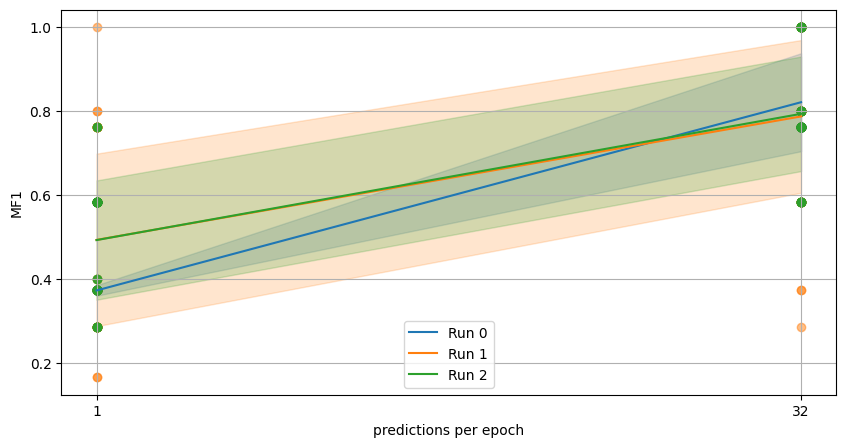

In [6]:
plt.figure(figsize=(10, 5))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]
for i, (model_run, mf1_scores_epoch) in enumerate(mf1_scores.items()):
    c = colors[i % len(colors)]
    means_to_plot = np.array(list(mf1_scores_epoch.values())).mean(axis=1)
    stds_to_plot = np.array(list(mf1_scores_epoch.values())).std(axis=1)
    plt.plot(range(len(mf1_scores_epoch)), means_to_plot, label=f"Run {i}", color=c)
    plt.fill_between(range(len(mf1_scores_epoch)), means_to_plot - stds_to_plot, means_to_plot + stds_to_plot,
                     alpha=0.2, color=c)
    plt.scatter(np.repeat(range(len(mf1_scores_epoch)), n_exps), np.array(list(mf1_scores_epoch.values())).flatten(),
                alpha=0.5, color=c)
first_key = next(iter(mf1_scores))
plt.xticks(range(len(mf1_scores[first_key])), list(mf1_scores[first_key].keys()))
plt.grid()
plt.xlabel("predictions per epoch")
plt.ylabel("MF1")
plt.legend()
plt.show()